# Import Libs

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from scipy.sparse import csr_matrix
from mlxtend.frequent_patterns import apriori, association_rules
import warnings 
warnings.filterwarnings("ignore")

# EDA

In [2]:
products =pd.read_csv("/kaggle/input/instacart-market-basket-analysis/products.csv")
order_products = pd.read_csv("/kaggle/input/instacart-market-basket-analysis/order_products__prior.csv")
df = pd.merge(order_products , products , on = "product_id" , how = "left")

df = df[["order_id" , "product_name"]]

df.head(10)

,order_id,product_name
0,2,Organic Egg Whites
1,2,Michigan Organic Kale
2,2,Garlic Powder
3,2,Coconut Butter
4,2,Natural Sweetener
5,2,Carrots
6,2,Original Unflavored Gelatine Mix
7,2,All Natural No Stir Creamy Almond Butter
8,2,Classic Blend Cole Slaw
9,3,Total 2% with Strawberry Lowfat Greek Strained...


# Preprocessing

In [3]:
top_products = df["product_name"].value_counts().head(50)

In [4]:
print(top_products)
top_products = top_products.index

product_name
Banana                                  472565
Bag of Organic Bananas                  379450
Organic Strawberries                    264683
Organic Baby Spinach                    241921
Organic Hass Avocado                    213584
Organic Avocado                         176815
Large Lemon                             152657
Strawberries                            142951
Limes                                   140627
Organic Whole Milk                      137905
Organic Raspberries                     137057
Organic Yellow Onion                    113426
Organic Garlic                          109778
Organic Zucchini                        104823
Organic Blueberries                     100060
Cucumber Kirby                           97315
Organic Fuji Apple                       89632
Organic Lemon                            87746
Apple Honeycrisp Organic                 85020
Organic Grape Tomatoes                   84255
Seedless Red Grapes                      82689


In [5]:
df_filtered = df[df["product_name"].isin(top_products)]
print(df_filtered.shape[0])

5373433


In [6]:
df_filtered["order_id"] = df_filtered["order_id"].astype("category")
df_filtered["product_name"] = df_filtered["product_name"].astype("category")

row = df_filtered["order_id"].cat.codes
col = df_filtered["product_name"].cat.codes
data = [1] * len(df_filtered)

sparse_basket = csr_matrix((data , (row , col)) , 
                          shape = (df_filtered["order_id"].nunique() , 
                                   df_filtered["product_name"].nunique())
                          )


In [7]:
basket_sets = pd.DataFrame.sparse.from_spmatrix(
    sparse_basket ,
    columns = df_filtered["product_name"].cat.categories.tolist()
)

basket_sets = basket_sets.astype(bool)

# Model

In [8]:
frequent_itemsets = apriori( basket_sets ,min_support = 0.01 ,use_colnames = True)

rules = association_rules(frequent_itemsets , metric = "lift" , min_threshold=1)

rules = rules.sort_values("lift" , ascending = False)

In [9]:
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(50))

                               antecedents  \
65                  (Organic Yellow Onion)   
64                        (Organic Garlic)   
44                           (Large Lemon)   
45                                 (Limes)   
66                         (Organic Lemon)   
67                  (Organic Hass Avocado)   
72                  (Organic Strawberries)   
73                   (Organic Raspberries)   
46                           (Large Lemon)   
47                       (Organic Avocado)   
63                   (Organic Blueberries)   
62                  (Organic Strawberries)   
51                       (Organic Avocado)   
50                                 (Limes)   
68                   (Organic Raspberries)   
69                  (Organic Hass Avocado)   
12  (Organic Large Extra Fancy Fuji Apple)   
13                (Bag of Organic Bananas)   
35                    (Organic Fuji Apple)   
34                                (Banana)   
56                        (Organic

# Result Visualization

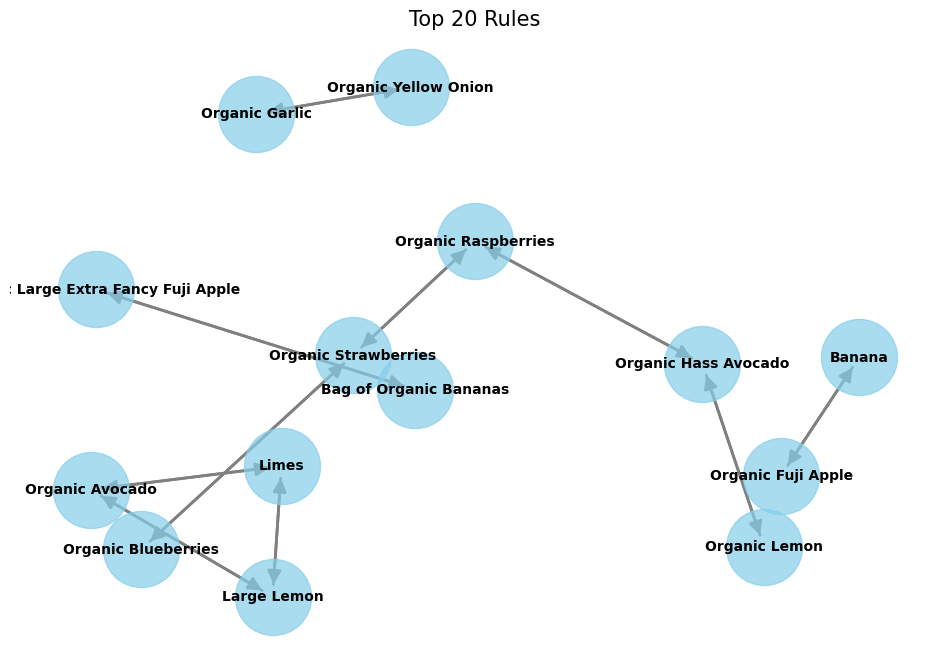

In [10]:
G = nx.DiGraph()

top_rules = rules.head(20)

for i, row in top_rules.iterrows():
    ant = list(row['antecedents'])[0]
    con = list(row['consequents'])[0]
    G.add_edge(ant, con, weight=row['lift'])

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, k=1.5)

nx.draw_networkx_nodes(G, pos, node_size=3000, node_color="skyblue", alpha=0.7)

nx.draw_networkx_edges(G, pos, width=2, edge_color="gray", arrowsize=20)

nx.draw_networkx_labels(G, pos, font_size=10, font_family="sans-serif", font_weight="bold")

plt.title("Top 20 Rules", size=15)
plt.axis('off')
plt.show()